In [1]:
!pip install sentence-transformers

In [2]:
sentences = [
    # Cricket (3)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket match by 5 wickets",

    # Cooking (3)
    "Add salt and spices while cooking the curry",
    "Boil the rice for 10 minutes",
    "Heat oil before frying vegetables",

    # Cybersecurity (4)
    "Use strong passwords to protect your account",
    "Hackers try to steal sensitive information",
    "Install antivirus software for protection",
    "Phishing attacks target user credentials"
]

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

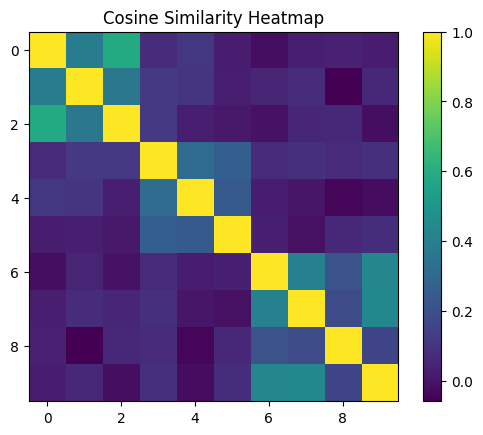

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(similarity_matrix)
plt.colorbar()
plt.title("Cosine Similarity Heatmap")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [8]:
import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", similarities[idx])
    print()

Sentence: The team won the cricket match by 5 wickets
Similarity Score: 0.7184911

Sentence: The batsman scored a century in the match
Similarity Score: 0.56821966

